Device: cuda
CSV path : /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Image dir: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder
Image files found: 16574
Loaded: light=1000, medium=1000, dark=1300
Classes: ['benign' 'malignant' 'non-neoplastic']
Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Loading images...
Extracting CLIP features (frozen)...
Features: light=(1000, 768), medium=(1000, 768), dark=(1300, 768)
Random-split upper-bound AUC: 0.8197

Fixed test set: n=1100, mitigation pool: n=200
Dark benign in test:          108 (0.098)
Dark benign in mitig pool:    18 (0.090)
nc/Ng (test): 0.0982  (paper: 0.0936)

DRO training set: 2200 samples, 9 groups
  Group  0 ( light × benign         ): n=146
  Group  1 ( light × malignant      ): n=161
  Group  2 ( light × non-neoplastic ): n=693
  Group  3 (medium × benign         ): n=129
  Group  4 (medium × malignant      ): n=125
  Group  5 (medium × non-neoplastic ): n=746
  Group  6 (  dark × benign         ): n=18
  Group  7 (  dark × malignant      ): n=23
  Group  8 (  dark × non-neoplastic ): n=159

ABLATION: 4 η values × 5 seeds = 20 runs

η = 0.001
  seed=42... benign_acc=0.000 auc=0.6475 min_wt=0.0916 collapse=False
  seed=0... benign_acc=0.000 auc=0.6457 min_wt=0.0907 collapse=False
  seed=1... benign_acc=

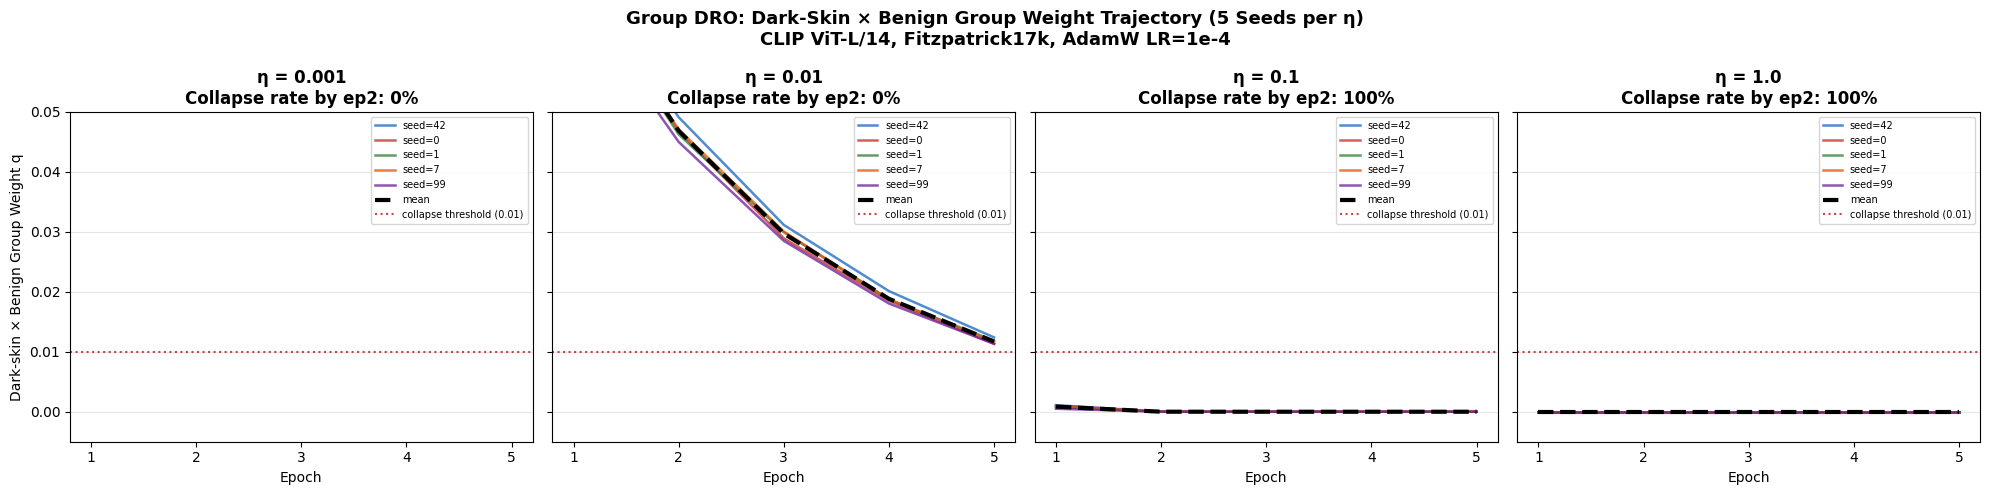

Figure saved: nb_eta_ablation_figure.png

=== SUMMARY TABLE: mean ± SD across 5 seeds ===
       η     Benign Acc     Demo AUC        SGG   Collapse Rate    Final Min Wt
--------------------------------------------------------------------------------
   0.001 0.000 ± 0.000    0.6398 ± 0.0243    0.1799 ± 0.0243    0% (0/5)    0.0910 ± 0.0004
    0.01 0.000 ± 0.000    0.6419 ± 0.0307    0.1777 ± 0.0307    0% (0/5)    0.0117 ± 0.0004
     0.1 0.076 ± 0.104    0.6363 ± 0.0325    0.1834 ± 0.0325    100% (5/5)    0.0000 ± 0.0000
     1.0 0.259 ± 0.370    0.5782 ± 0.0273    0.2414 ± 0.0273    100% (5/5)    0.0000 ± 0.0000

=== LaTeX TABLE ROWS ===
% Random-split AUC upper bound = 0.8197
% nc/Ng (dark test set) = 0.0982 (paper baseline: 0.0936)
\eta & Benign Acc & Demo AUC & SGG & Collapse Rate (n=5) & Final Minority Wt \\
\hline
0.001 & 0.000 $\pm$ 0.000 & 0.6398 $\pm$ 0.0243 & 0.1799 $\pm$ 0.0243 & 0/5 & 0.0910 $\pm$ 0.0004 \\
0.01 & 0.000 $\pm$ 0.000 & 0.6419 $\pm$ 0.0307 & 0.1777 $\pm$ 0.0

In [14]:
# ============================================================
# Group DRO Learning Rate (η) Ablation — 5 Seeds
# CLIP ViT-L/14, Fitzpatrick17k
# GPU T4, Internet ON. ~50 min.
#
# WHY: The original paper used 2 seeds per η, which reviewers
# flagged as insufficient to establish stability of the weight-
# collapse finding. This notebook runs 5 seeds per η (20 total
# runs) to confirm that minority group weight collapse and
# near-zero benign accuracy are robust across random init and
# batch ordering — not an artifact of a lucky/unlucky seed.
#
# PRIMARY QUESTION:
#   Does dark-skin×benign group weight collapse (< 0.01 by
#   epoch 2) appear consistently at high η values?
#   Does benign accuracy stay near-zero across ALL η ∈ {0.01–1.0}?
#   If yes for both: strengthens MAD claim that DRO structurally
#   fails to recover per-class accuracy regardless of learning rate.
#
# DESIGN:
#   Backbone: CLIP ViT-L/14 (FROZEN) — extract features once, cache.
#   Classifier: nn.Linear(768→3), AdamW LR=1e-4, weight_decay=1e-4.
#   DRO η: exponentiated gradient step for group weight updates
#           (Sagawa et al. 2020, Algorithm 1). NOT the AdamW LR.
#   Groups: skin_tone × label → 9 groups (3 skin × 3 classes).
#   Minority group tracked: dark-skin × benign (group 6).
#   Split: train Fitzpatrick I–IV (light+medium 1000 each) +
#          200 dark-skin mitigation pool.
#          Test: Fitzpatrick V–VI (n≈800), fixed across all runs.
#   5 epochs, batch size 32, L2-normalized features.
#
# SEEDS: {42, 0, 1, 7, 99} per η. η ∈ {0.001, 0.01, 0.1, 1.0}.
#
# CSV SAVE: After every η completes (not at end — so partial runs
# are recoverable). File: eta_ablation_results.csv.
#
# OUTPUTS:
#   eta_ablation_results.csv       — one row per (η, seed)
#   eta_ablation_weight_traj.json  — epoch-by-epoch group weights
#   nb_eta_ablation_figure.png     — 4-panel weight trajectory plot
#   (+ LaTeX table rows + plain summary printed at end)
#
# Kaggle: GPU T4 x1, Internet ON
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, json, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
BASE_SEED    = 42
ETA_VALUES   = [0.001, 0.01, 0.1, 1.0]
SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 5
BATCH_SIZE   = 32
ADAMW_LR     = 1e-4
ADAMW_WD     = 1e-4
N_GROUPS     = 9        # 3 skin tones × 3 classes
FEAT_DIM     = 768
N_CLASSES    = 3
N_DARK_MITIG = 200      # dark images added to training pool
COLLAPSE_THR = 0.01     # minority weight below this = weight collapse
NC_NG_PAPER  = 203 / 2168  # ~0.0937, Fitzpatrick17k benign fraction in dark test (paper: 203/2168 = 9.4%)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Dataset path auto-discovery ───────────────────────────────
# Find the Fitzpatrick CSV then use its parent directory for images
# (both always live in the same folder on this Kaggle dataset).
_fitz_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_root, _f)
            break
    if _fitz_csv:
        break

if _fitz_csv:
    fitz_csv     = _fitz_csv
    fitz_img_dir = os.path.dirname(_fitz_csv)   # CSV and images share the same dir
else:
    fitz_csv     = '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
    fitz_img_dir = '/kaggle/input/fitzpatrick17k/images'

print(f"CSV path : {fitz_csv}")
print(f"Image dir: {fitz_img_dir}")

# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv(fitz_csv)
df = df[df['fitzpatrick_scale'] > 0]
image_files = {}
for _img_root, _img_dirs, _img_files in os.walk(fitz_img_dir):
    for _img_f in _img_files:
        if _img_f.endswith('.jpg') or _img_f.endswith('.png'):
            _key = _img_f.replace('.jpg', '').replace('.png', '')
            image_files[_key] = os.path.join(_img_root, _img_f)
print(f"Image files found: {len(image_files)}")
df['local_path'] = df['md5hash'].map(image_files)
df = df[df['local_path'].notna()].copy()
df['skin_group'] = df['fitzpatrick_scale'].apply(
    lambda x: 'light' if x <= 2 else ('medium' if x <= 4 else 'dark'))

np.random.seed(BASE_SEED)
MAX = 1000
light_df  = df[df['skin_group']=='light'].sample(MAX, random_state=BASE_SEED)
medium_df = df[df['skin_group']=='medium'].sample(MAX, random_state=BASE_SEED)
dark_df   = df[df['skin_group']=='dark'].copy()
if len(dark_df) > 1300:
    dark_df = dark_df.sample(1300, random_state=BASE_SEED)
print(f"Loaded: light={len(light_df)}, medium={len(medium_df)}, dark={len(dark_df)}")

le = LabelEncoder()
le.fit(list(light_df['three_partition_label']) +
       list(medium_df['three_partition_label']) +
       list(dark_df['three_partition_label']))
print(f"Classes: {le.classes_}")  # expect: benign, malignant, non-neoplastic

BENIGN_IDX  = int(list(le.classes_).index('benign'))
MALIG_IDX   = int(list(le.classes_).index('malignant'))
NONNEO_IDX  = int(list(le.classes_).index('non-neoplastic'))
# Minority group index: dark(=2) × n_classes + benign_idx
MINORITY_G  = 2 * N_CLASSES + BENIGN_IDX   # group 6

# ── Load CLIP ─────────────────────────────────────────────────
print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")

def load_imgs(dataframe):
    imgs, lbls = [], []
    for _, row in dataframe.iterrows():
        try:
            img = Image.open(row['local_path']).convert('RGB').resize((224, 224))
            imgs.append(img)
            lbls.append(le.transform([row['three_partition_label']])[0])
        except:
            pass
    return imgs, np.array(lbls)

@torch.no_grad()
def get_features(images, batch_size=32):
    all_feats = []
    for i in range(0, len(images), batch_size):
        batch  = images[i:i+batch_size]
        inputs = clip_proc(images=batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats  = clip_model.get_image_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output if hasattr(feats, 'pooler_output') \
                    else feats.last_hidden_state[:,0]
        feats  = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
    return np.vstack(all_feats)

# ── Extract features ──────────────────────────────────────────
print("Loading images...")
light_imgs,  light_y  = load_imgs(light_df)
medium_imgs, medium_y = load_imgs(medium_df)
dark_imgs,   dark_y   = load_imgs(dark_df)

print("Extracting CLIP features (frozen)...")
light_feats  = get_features(light_imgs)
medium_feats = get_features(medium_imgs)
dark_feats   = get_features(dark_imgs)
print(f"Features: light={light_feats.shape}, medium={medium_feats.shape}, dark={dark_feats.shape}")

# ── Compute random-split upper-bound AUC ─────────────────────
# Needed for SGG = AUC_rand − AUC_demo. Fixed once (no seed variation here).
from sklearn.linear_model import LogisticRegression
all_f = np.vstack([light_feats, medium_feats, dark_feats])
all_y = np.concatenate([light_y, medium_y, dark_y])
tr_idx, te_idx = train_test_split(np.arange(len(all_y)), test_size=0.25,
                                   stratify=all_y, random_state=BASE_SEED)
clf_rand = LogisticRegression(max_iter=1000, C=1.0, random_state=BASE_SEED)
clf_rand.fit(all_f[tr_idx], all_y[tr_idx])
RAND_AUC = roc_auc_score(all_y[te_idx], clf_rand.predict_proba(all_f[te_idx]),
                          multi_class='ovr', average='macro')
print(f"Random-split upper-bound AUC: {RAND_AUC:.4f}")

# ── Fixed test/pool split ─────────────────────────────────────
# Test set is FIXED for all runs. Pool comes from remainder.
# Mitigation pool comes first; test set is ALL remaining dark images
# (paper: test set = all Fitzpatrick V-VI not in the mitigation pool)
# Shuffle dark features first — CSV ordering may be sorted by condition/skin
# type, so an unshuffled slice would introduce systematic bias.
perm         = np.random.RandomState(BASE_SEED).permutation(len(dark_feats))
dark_feats_s = dark_feats[perm]
dark_y_s     = dark_y[perm]
n_pool   = min(N_DARK_MITIG, len(dark_feats_s))
mitig_f  = dark_feats_s[:n_pool]
mitig_y  = dark_y_s[:n_pool]
test_f   = dark_feats_s[n_pool:]   # all remaining dark images
test_y   = dark_y_s[n_pool:]
print(f"\nFixed test set: n={len(test_f)}, mitigation pool: n={n_pool}")
print(f"Dark benign in test:          {(test_y  == BENIGN_IDX).sum()} "
      f"({(test_y  == BENIGN_IDX).mean():.3f})")
print(f"Dark benign in mitig pool:    {(mitig_y == BENIGN_IDX).sum()} "
      f"({(mitig_y == BENIGN_IDX).mean():.3f})")
print(f"nc/Ng (test): {(test_y == BENIGN_IDX).mean():.4f}  "
      f"(paper: {NC_NG_PAPER:.4f})")

# ── Helpers ───────────────────────────────────────────────────
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom  = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def eval_benign(preds, labels, benign_idx):
    mask = labels == benign_idx
    if mask.sum() == 0:
        return 0.0, 0.0, 0.0
    k = int(accuracy_score(labels[mask], preds[mask]) * mask.sum())
    n = int(mask.sum())
    acc = k / n
    lo, hi = wilson_ci(k, n)
    return acc, lo, hi

# ── Group assignment for DRO ──────────────────────────────────
# skin_id: light=0, medium=1, dark=2
# group_id = skin_id * N_CLASSES + class_label ∈ {0..8}
light_skin  = np.zeros(len(light_feats), dtype=int)   # skin_id=0
medium_skin = np.ones(len(medium_feats), dtype=int)    # skin_id=1
dark_skin   = np.full(len(mitig_f), 2, dtype=int)      # skin_id=2

base_f     = np.vstack([light_feats, medium_feats, mitig_f])
base_y     = np.concatenate([light_y, medium_y, mitig_y])
base_skin  = np.concatenate([light_skin, medium_skin, dark_skin])
base_groups = (base_skin * N_CLASSES + base_y).astype(int)
n_train    = len(base_f)

print(f"\nDRO training set: {n_train} samples, {N_GROUPS} groups")
for g in range(N_GROUPS):
    skin_id  = g // N_CLASSES
    cls_id   = g  % N_CLASSES
    skin_lbl = ['light','medium','dark'][skin_id]
    cls_lbl  = le.classes_[cls_id]
    n_g      = (base_groups == g).sum()
    print(f"  Group {g:>2} ({skin_lbl:>6} × {cls_lbl:<15}): n={n_g}")

# ── DRO training function (PyTorch, AdamW) ────────────────────
# η = DRO exponentiated gradient step (Sagawa 2020, Alg. 1).
# AdamW LR = ADAMW_LR (fixed across all ablation runs).
# Returns per-epoch minority weight + evaluation metrics.
def run_dro(eta_dro, seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)

    # Linear classification head on frozen CLIP features
    head = nn.Linear(FEAT_DIM, N_CLASSES).to(device)
    nn.init.xavier_uniform_(head.weight)
    nn.init.zeros_(head.bias)
    optimizer = optim.AdamW(head.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    criterion = nn.CrossEntropyLoss(reduction='none')

    # DataLoader — shuffle with seed-controlled generator
    gen = torch.Generator()
    gen.manual_seed(seed)
    X_t = torch.tensor(base_f,      dtype=torch.float32)
    Y_t = torch.tensor(base_y,      dtype=torch.long)
    G_t = torch.tensor(base_groups, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, Y_t, G_t),
                        batch_size=BATCH_SIZE, shuffle=True, generator=gen)

    # Group weights (uniform init)
    q = torch.ones(N_GROUPS, device=device) / N_GROUPS

    epoch_minority_weights = []
    weight_collapse_by_ep2 = False

    for epoch in range(N_EPOCHS):
        head.train()

        for xb, yb, gb in loader:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            logits = head(xb)
            losses = criterion(logits, yb)  # (batch,)

            # Weighted loss for model update: Σ_g q_g * mean_loss_g
            # Use zeros(1, requires_grad=True) so the graph is valid even if
            # no groups are active in this batch (avoids a detached-tensor edge case).
            total_loss = torch.zeros(1, device=device, requires_grad=True).squeeze()
            batch_group_losses = torch.zeros(N_GROUPS, device=device)
            for g in range(N_GROUPS):
                mask_g = (gb == g)
                if mask_g.sum() > 0:
                    gl = losses[mask_g].mean()
                    total_loss = total_loss + q[g].detach() * gl
                    batch_group_losses[g] = gl.detach()

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            # DRO weight update: q_g ← q_g * exp(η * loss_g)
            with torch.no_grad():
                active = batch_group_losses > 0
                q[active] = q[active] * torch.exp(
                    torch.tensor(eta_dro, device=device) * batch_group_losses[active])
                q = q / q.sum()

        # Per-epoch minority weight
        min_wt = float(q[MINORITY_G].item())
        epoch_minority_weights.append(min_wt)

        if epoch == 1:  # 0-indexed epoch 1 = "by epoch 2"
            weight_collapse_by_ep2 = (min_wt < COLLAPSE_THR)

    # Evaluate on dark-skin test set
    head.eval()
    with torch.no_grad():
        test_t  = torch.tensor(test_f, dtype=torch.float32).to(device)
        logits  = head(test_t)
        probs   = torch.softmax(logits, dim=-1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)

    benign_acc, ci_lo, ci_hi = eval_benign(preds, test_y, BENIGN_IDX)
    try:
        demo_auc = roc_auc_score(test_y, probs, multi_class='ovr', average='macro')
    except ValueError:
        demo_auc = float('nan')

    return {
        'benign_acc':             float(benign_acc),
        'benign_ci_lo':           float(ci_lo),
        'benign_ci_hi':           float(ci_hi),
        'demo_auc':               float(demo_auc),
        'sgg':                    float(RAND_AUC - demo_auc),
        'final_minority_weight':  float(q[MINORITY_G].item()),
        'weight_collapse_by_ep2': bool(weight_collapse_by_ep2),
        'epoch_minority_weights': epoch_minority_weights,
    }

# ── Main ablation loop ────────────────────────────────────────
all_rows     = []
traj_log     = {}
csv_path     = '/kaggle/working/eta_ablation_results.csv'
traj_path    = '/kaggle/working/eta_ablation_weight_traj.json'

print("\n" + "="*70)
print(f"ABLATION: {len(ETA_VALUES)} η values × {len(SEEDS)} seeds = {len(ETA_VALUES)*len(SEEDS)} runs")
print("="*70)

for eta in ETA_VALUES:
    eta_key  = str(eta)
    traj_log[eta_key] = {}
    eta_rows = []
    print(f"\nη = {eta}")

    for seed in SEEDS:
        print(f"  seed={seed}...", end=' ', flush=True)
        res = run_dro(eta, seed)
        row = {
            'eta':                    eta,
            'seed':                   seed,
            'benign_acc':             res['benign_acc'],
            'benign_ci_lo':           res['benign_ci_lo'],
            'benign_ci_hi':           res['benign_ci_hi'],
            'demo_auc':               res['demo_auc'],
            'sgg':                    res['sgg'],
            'final_minority_weight':  res['final_minority_weight'],
            'weight_collapse_by_ep2': res['weight_collapse_by_ep2'],
        }
        print(f"benign_acc={res['benign_acc']:.3f} "
              f"auc={res['demo_auc']:.4f} "
              f"min_wt={res['final_minority_weight']:.4f} "
              f"collapse={res['weight_collapse_by_ep2']}")
        eta_rows.append(row)
        all_rows.append(row)
        traj_log[eta_key][str(seed)] = res['epoch_minority_weights']

    # Save CSV after each η (recoverable on timeout)
    pd.DataFrame(all_rows).to_csv(csv_path, index=False)
    print(f"  → CSV saved ({len(all_rows)} rows so far)")

# Save trajectory log
json.dump({'rand_auc': RAND_AUC, 'trajectories': traj_log},
          open(traj_path, 'w'), indent=2)

# ── Figure: minority group weight trajectories ────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle(
    'Group DRO: Dark-Skin × Benign Group Weight Trajectory (5 Seeds per η)\n'
    'CLIP ViT-L/14, Fitzpatrick17k, AdamW LR=1e-4',
    fontsize=13, fontweight='bold'
)

SEED_COLORS = ['#1565C0','#C62828','#2E7D32','#E65100','#6A1B9A']
EPOCHS      = list(range(1, N_EPOCHS + 1))

for ax_i, eta in enumerate(ETA_VALUES):
    ax  = axes[ax_i]
    eta_key = str(eta)
    seed_trajs = []
    for s_i, seed in enumerate(SEEDS):
        traj = traj_log[eta_key][str(seed)]
        ax.plot(EPOCHS, traj, color=SEED_COLORS[s_i],
                linewidth=1.8, alpha=0.75, label=f'seed={seed}')
        seed_trajs.append(traj)

    # Mean trajectory (bold)
    mean_traj = np.mean(seed_trajs, axis=0)
    ax.plot(EPOCHS, mean_traj, color='black', linewidth=3.0,
            linestyle='--', label='mean')

    # Collapse threshold line
    ax.axhline(COLLAPSE_THR, color='#B71C1C', linewidth=1.5,
               linestyle=':', alpha=0.8, label=f'collapse threshold ({COLLAPSE_THR})')

    # Mark epoch-2 collapse rate
    collapse_rows = [r for r in all_rows
                     if r['eta'] == eta and r['weight_collapse_by_ep2']]
    collapse_rate  = len(collapse_rows) / len(SEEDS)
    ax.set_title(f'η = {eta}\nCollapse rate by ep2: {collapse_rate:.0%}',
                 fontweight='bold')
    ax.set_xlabel('Epoch')
    if ax_i == 0:
        ax.set_ylabel('Dark-skin × Benign Group Weight q')
    ax.set_xticks(EPOCHS)
    ax.set_xlim(0.8, N_EPOCHS + 0.2)
    ax.set_ylim(-0.005, max(0.05, min(0.35, max([
        max(traj_log[str(eta)][str(s)]) for s in SEEDS]) + 0.02)))
    ax.yaxis.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('/kaggle/working/nb_eta_ablation_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: nb_eta_ablation_figure.png")

# ── Summary table ─────────────────────────────────────────────
df_res = pd.DataFrame(all_rows)
print("\n=== SUMMARY TABLE: mean ± SD across 5 seeds ===")
print(f"{'η':>8} {'Benign Acc':>14} {'Demo AUC':>12} {'SGG':>10} "
      f"{'Collapse Rate':>15} {'Final Min Wt':>15}")
print("-" * 80)
for eta in ETA_VALUES:
    sub   = df_res[df_res['eta'] == eta]
    ba    = sub['benign_acc'].mean();       ba_s = sub['benign_acc'].std()
    auc   = sub['demo_auc'].mean();         auc_s = sub['demo_auc'].std()
    sgg   = sub['sgg'].mean();              sgg_s = sub['sgg'].std()
    mwt   = sub['final_minority_weight'].mean()
    mwt_s = sub['final_minority_weight'].std()
    cr    = sub['weight_collapse_by_ep2'].mean()
    print(f"{eta:>8} {ba:.3f} ± {ba_s:.3f}  "
          f"  {auc:.4f} ± {auc_s:.4f}  "
          f"  {sgg:.4f} ± {sgg_s:.4f}  "
          f"  {cr:.0%} ({int(cr*len(SEEDS))}/{len(SEEDS)})  "
          f"  {mwt:.4f} ± {mwt_s:.4f}")

# ── LaTeX table rows ──────────────────────────────────────────
print("\n=== LaTeX TABLE ROWS ===")
print(f"% Random-split AUC upper bound = {RAND_AUC:.4f}")
print(f"% nc/Ng (dark test set) = {(test_y == BENIGN_IDX).mean():.4f} "
      f"(paper baseline: {NC_NG_PAPER:.4f})")
print(f"\\eta & Benign Acc & Demo AUC & SGG & Collapse Rate (n=5) & "
      f"Final Minority Wt \\\\")
print("\\hline")
for eta in ETA_VALUES:
    sub   = df_res[df_res['eta'] == eta]
    ba    = sub['benign_acc'].mean();       ba_s = sub['benign_acc'].std()
    auc   = sub['demo_auc'].mean();         auc_s = sub['demo_auc'].std()
    sgg   = sub['sgg'].mean();              sgg_s = sub['sgg'].std()
    mwt   = sub['final_minority_weight'].mean()
    cr    = sub['weight_collapse_by_ep2'].mean()
    n_col = int(cr * len(SEEDS))
    print(f"{eta} & {ba:.3f} $\\pm$ {ba_s:.3f} & {auc:.4f} $\\pm$ {auc_s:.4f} & "
          f"{sgg:.4f} $\\pm$ {sgg_s:.4f} & {n_col}/{len(SEEDS)} & "
          f"{mwt:.4f} $\\pm$ {sub['final_minority_weight'].std():.4f} \\\\")

# ── Key interpretation flags ──────────────────────────────────
print("\n=== INTERPRETATION FLAGS ===")
zero_benign_rows = df_res[df_res['benign_acc'] < 0.01]
print(f"Runs with benign_acc < 0.01:  {len(zero_benign_rows)}/{len(df_res)} "
      f"({len(zero_benign_rows)/len(df_res):.0%})")
high_eta_rows = df_res[df_res['eta'] >= 0.1]
print(f"High-η (≥0.1) collapse rate:  "
      f"{high_eta_rows['weight_collapse_by_ep2'].mean():.0%} "
      f"({int(high_eta_rows['weight_collapse_by_ep2'].sum())}/{len(high_eta_rows)})")
low_eta_rows  = df_res[df_res['eta'] <= 0.01]
print(f"Low-η  (≤0.01) benign acc:    "
      f"{low_eta_rows['benign_acc'].mean():.3f} ± "
      f"{low_eta_rows['benign_acc'].std():.3f} (still near-zero?)")

# ── Full per-run table ────────────────────────────────────────
print("\n=== FULL PER-RUN TABLE ===")
print(f"{'η':>8} {'seed':>6} {'benign_acc':>12} {'CI':>20} {'demo_auc':>10} "
      f"{'sgg':>8} {'min_wt':>10} {'collapse':>10}")
for _, row in df_res.iterrows():
    ci_str = f"({row['benign_ci_lo']:.3f}–{row['benign_ci_hi']:.3f})"
    print(f"{row['eta']:>8} {row['seed']:>6} {row['benign_acc']:>12.3f} "
          f"{ci_str:>20} {row['demo_auc']:>10.4f} {row['sgg']:>8.4f} "
          f"{row['final_minority_weight']:>10.4f} {str(row['weight_collapse_by_ep2']):>10}")

print(f"\n✓ Complete.")
print(f"Files: nb_eta_ablation_figure.png, eta_ablation_results.csv, eta_ablation_weight_traj.json")
print(f"Upload figure + paste ALL output (especially LaTeX rows) to Claude.")

In [9]:
fitz_csv     = '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
fitz_img_dir = '/kaggle/input/fitzpatrick17k/images'